## Setting

In [12]:
#import json
import pandas as pd
#import requests
#from requests.adapters import HTTPAdapter
#from requests.packages.urllib3.util.retry import Retry
#from requests import status_codes
#from pytrends import exceptions
from urllib.parse import quote
import datetime
from datetime import datetime, date, time
import time
import matplotlib.pyplot as plt
import numpy as np
import random
import sys
from pathlib import Path
import statsmodels.api as sm

In [4]:
# Clone Git Repo and retreive rkeywords sets, raw data again
REPO = "gasoline-price-search-index"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = Path("/content") / REPO
    if ROOT.exists():
        !git -C {ROOT} pull -q
    else:
        !git clone -q https://github.com/YBcho02/{REPO}.git {ROOT}
else:
    ROOT = Path.cwd().parent

sys.path.append(str(ROOT / "src"))
from keywords import KEYWORDS, ANCHOR
print(f"{len(KEYWORDS)} keywords, anchor = '{ANCHOR}'")

61 keywords, anchor = 'gas price'


In [19]:
RAW  = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
OUTPUT = ROOT / "output"
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)
OUTPUT.mkdir(parents = True, exist_ok = True)

## Scaling SVI

See Appendix A.3. of Bae, Jo, and Shim (2022)

Bae, Siye and Jo, Soojin and Shim, Myung-Kyu, United States of Mind Under Uncertainty. Available at SSRN: https://ssrn.com/abstract=4309872 or http://dx.doi.org/10.2139/ssrn.4309872

In [6]:
#Retrieve collected data
Wdata_Wgs_weight_only = pd.read_csv('/content/gasoline-price-search-index/data/raw/gtrends_anchor_ratios.csv', index_col=0)
Wdata = pd.read_csv('/content/gasoline-price-search-index/data/raw/gtrends_single_terms.csv', index_col=0)

In [7]:
# getting a scaled SVI
Wdata_Wgs_weight_only_idx = Wdata_Wgs_weight_only.reset_index(drop = True)
Wdata_max=Wdata.copy()
for i in Wdata.columns:
  if i == 'gas price':
    Wdata_max[i] = Wdata[i]
  else:
    idx = Wdata_Wgs_weight_only_idx.idxmax()[i]
    if Wdata_Wgs_weight_only_idx.max()[i] == 0 :
      Wdata_max[i]=0
    else:
      Wdata_max[i]=(Wdata[i])*(((Wdata_Wgs_weight_only_idx[i].iloc[idx])*(Wdata['gas price'].iloc[idx]))/(Wdata[i].iloc[idx]))

In [8]:
Wdata_max.to_csv(PROC / 'svi_rescaled.csv')

## Seasonality Adjustment in mac and Winsorizing

we address
seasonality using the X13-ARIMA-SEATS and remove outliers by winsorizing each series at the
5% level (2.5% in each tail)



In [9]:
!wget -q https://www2.census.gov/software/x-13arima-seats/x13as/unix-linux/program-archives/x13as_ascii-v1-1-b62.tar.gz
!tar -xzf x13as_ascii-v1-1-b62.tar.gz

import glob, os, shutil, subprocess

cands = (glob.glob('**/x13as_ascii.exe', recursive=True)
         + glob.glob('**/x13as_ascii', recursive=True)
         + glob.glob('**/x13as', recursive=True))
print("found:", cands)

dest = '/usr/local/bin/x13as'
shutil.copy(cands[0], dest)
os.chmod(dest, 0o755)
os.environ['X13PATH'] = '/usr/local/bin'

print(subprocess.run([dest], capture_output=True, text=True).stdout[:400])

found: ['x13as/x13as_ascii', 'x13as']

 X-13ARIMA-SEATS Seasonal Adjustment Program
 Version Number 1.1 Build 62
 Execution began  Sep 11, 2026  14.04.33 

 ERROR: Must specify either an input specification file name
        (-i infile or infile) or an input metafile name (-m metafile).

        See Section 2 of the X-13ARIMA-SEATS Reference Manual for more
        information on how to run X-13ARIMA-SEATS.



In [13]:


X13 = '/usr/local/bin'
MIN_OBS = 36

W = Wdata_max.copy()
W.index = pd.PeriodIndex(W.index, freq='M')

seasadj, trend, irregular = {}, {}, {}
skipped = {}

for col in W.columns:
    s = W[col].astype(float)


    s = s.loc[s.first_valid_index():s.last_valid_index()] if s.notna().any() else s

    if s.isna().any():
        skipped[col] = f"{int(s.isna().sum())} interior NaNs"
        continue
    if len(s) < MIN_OBS:
        skipped[col] = f"only {len(s)} obs"
        continue

    use_log = bool(s.min() > 0)   # multiplicative needs strictly positive

    try:
        res = sm.tsa.x13_arima_analysis(
            s, x12path=X13, prefer_x13=True, outlier=True, trading = True
        )
        seasadj[col]   = res.seasadj
        trend[col]     = res.trend
        irregular[col] = res.irregular
        print(f"OK   {col}  (n={len(s)}, log={use_log})")
    except Exception as e:
        skipped[col] = f"{type(e).__name__}: {e}"
        print(f"FAIL {col}: {type(e).__name__}: {e}")

Wdata_max_sa    = pd.DataFrame(seasadj).reindex(index=W.index, columns=W.columns)
Wdata_max_trend = pd.DataFrame(trend).reindex(index=W.index, columns=W.columns)
Wdata_max_irr   = pd.DataFrame(irregular).reindex(index=W.index, columns=W.columns)

print(f"\nAdjusted {len(seasadj)}/{len(W.columns)}. Skipped:")
for k, v in skipped.items():
    print(f"  {k}: {v}")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/x13.py:644: X13Warning: WARNING: At least one visually significant trading day peak has been
          found in one or more of the estimated spectra.
  _check_errors(errors, rawspec)


OK   average gas prices  (n=200, log=True)
OK   average price of gas  (n=200, log=True)
OK   best gas mileage  (n=200, log=True)
OK   best gas mileage car  (n=200, log=True)
OK   best gas mileage cars  (n=200, log=True)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/x13.py:644: X13Warning: WARNING: At least one visually significant trading day peak has been
          found in one or more of the estimated spectra.
  _check_errors(errors, rawspec)


OK   best gas prices  (n=200, log=True)
OK   best suv gas mileage  (n=200, log=True)
OK   ca gas prices  (n=200, log=True)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/x13.py:644: X13Warning: WARNING: At least one visually significant trading day peak has been
          found in the estimated spectrum of the regARIMA residuals.
  
          found in one or more of the estimated spectra.
  _check_errors(errors, rawspec)


...

OK   speedway  (n=200, log=True)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/x13.py:644: X13Warning: WARNING: At least one visually significant seasonal peak has been found
          in the estimated spectrum of the regARIMA residuals.
  _check_errors(errors, rawspec)


OK   subaru gas mileage  (n=200, log=True)
OK   us gas prices  (n=200, log=True)
OK   walmart gas  (n=200, log=True)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/x13.py:644: X13Warning: WARNING: Automatic transformation selection cannot be done on a
          series with zero or negative values.
  
          been found in the estimated spectrum of the regARIMA residuals.
  
          found in one or more of the estimated spectra.
  _check_errors(errors, rawspec)


OK   walmart gas price  (n=200, log=False)
OK   what is gasoline  (n=200, log=True)
OK   what is in gasoline  (n=200, log=True)

Adjusted 58/61. Skipped:
  gas price today: X13Error: ERROR: Adding AO2024.Oct exceeds the number of regression effects allowed
        in the model (80).

        Check the regression model, change the automatic outlier options,
        (e.g. method to ADDONE, raise the critical value, or change types
        to identify AOs only), or change the program limits (see Section 2.7
        of the X-13ARIMA-SEATS Reference Manual).
  sam's gas price: X13Error: WARNING: Automatic transformation selection cannot be done on a
          series with zero or negative values.

 ERROR: Adding LS2018.Oct exceeds the number of regression effects allowed
        in the model (80).

        Check the regression model, change the automatic outlier options,
        (e.g. method to ADDONE, raise the critical value, or change types
        to identify AOs only), or change the pro

In [15]:
Wdata_max_sa.to_csv(PROC / 'svi_rescaled_sa.csv')

### Winscorizing

In [16]:
Wdata_max_yes0=Wdata_max_sa.copy()
Wdata_max_yes0_wns=Wdata_max_yes0.copy()

for i in range(len(Wdata_max_yes0)):
    for j in Wdata_max_yes0.columns.tolist():
        if Wdata_max_yes0[j].iloc[i] < Wdata_max_yes0.quantile(q=0.025)[j]:
            Wdata_max_yes0_wns[j].iloc[i] = Wdata_max_yes0.quantile(q=0.025)[j]
        elif Wdata_max_yes0[j].iloc[i] > Wdata_max_yes0.quantile(q=0.975)[j]:
            Wdata_max_yes0_wns[j].iloc[i] = Wdata_max_yes0.quantile(q=0.975)[j]

Streaming output truncated to the last 5000 lines.

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Wdata_max_yes0_wns[j].iloc[i] = Wdata_max_yes0.quantile(q=0.025)[j]
/tmp/ipykernel_1130/4233253473.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = valu

## Composite Index

All the re-scaled and adjusted series are aggregated into a single series. Then, it is normalized so that the first data point (2010M01) is indexed to 100.

In [17]:
index_level_260828=pd.DataFrame()
index_level_260828['total index']=Wdata_max_yes0_wns[Wdata_max_yes0_wns.columns].sum(axis=1)
for i in index_level_260828.columns:
    index_level_260828[i]=index_level_260828[i].div(index_level_260828[i].iloc[0])*100

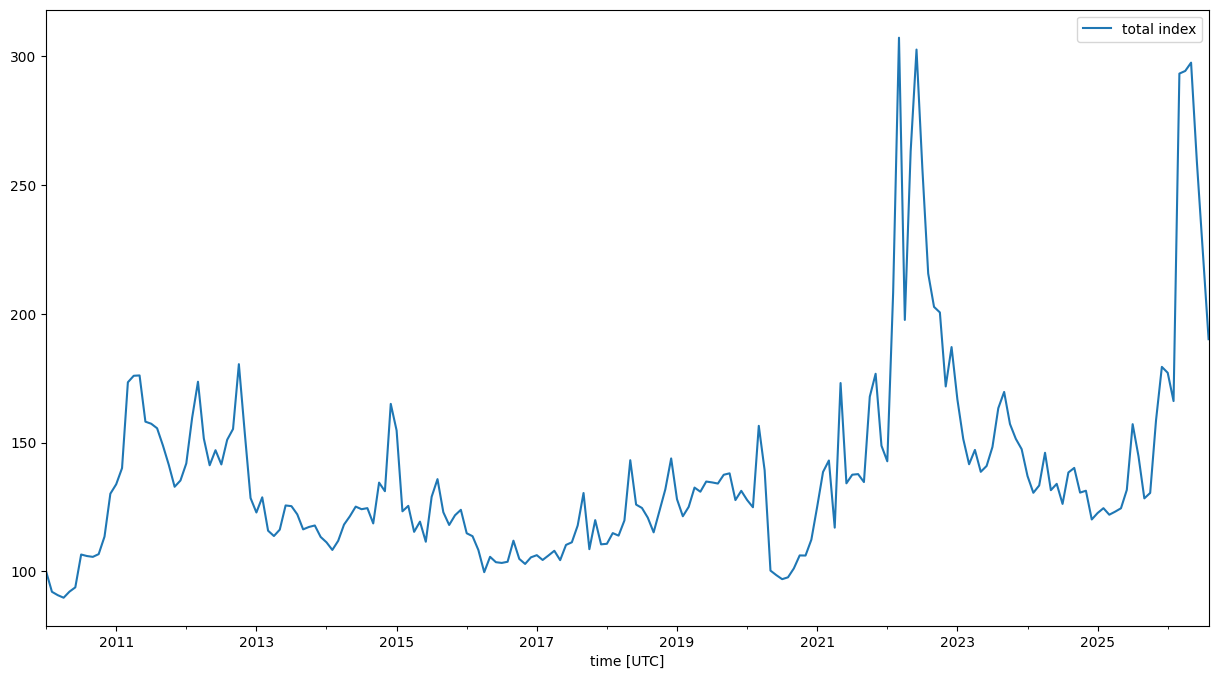

In [21]:
index_level_260828.plot(figsize=(15, 8))
index_level_260828.to_csv(PROC / 'gps_index.csv')